In [1]:
# ── Cell 1 — Libraries ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [2]:
# ── Cell 2 — Load Data ────────────────────────────────────────────────
ts_df = pd.read_csv(
    r'F:\projectss\personal\blinkit_project\data\processed\ts_features.csv'
)
ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])

print(f"Loaded rows : {len(ts_df):,}")
print(f"Columns     : {ts_df.shape[1]}")

Loaded rows : 1,975,538
Columns     : 46


In [3]:
# ── Cell 3 — Define Features and Target ──────────────────────────────
FEATURES = [
    # time features
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'week_sin', 'week_cos',
    'month',

    # lag features
    'lag_1', 'lag_24', 'lag_48', 'lag_168',

    # rolling features
    'rolling_mean_24', 'rolling_mean_168', 'rolling_mean_720',
    'rolling_std_24',  'rolling_std_168',
    'rolling_max_24',  'rolling_max_168',
    'ewma_24',         'ewma_168',

    # weather features
    'temperature', 'rainfall', 'humidity',
    'is_raining',  'is_hot',   'is_cold', 'is_humid',

    # festival and time features
    'is_festival', 'is_weekend',
    'is_peak_hour', 'is_night', 'is_morning',
]

TARGET = 'demand_log'   # use log transformed demand

# drop rows where any feature is NaN
model_df = ts_df.dropna(subset=FEATURES + [TARGET]).copy()

print(f"Rows before dropna : {len(ts_df):,}")
print(f"Rows after dropna  : {len(model_df):,}")
print(f"Total features     : {len(FEATURES)}")

Rows before dropna : 1,975,538
Rows after dropna  : 1,975,538
Total features     : 32


In [4]:
# ── Cell 4 — Train Test Split ─────────────────────────────────────────
# last 2 weeks = test, rest = train
cutoff = model_df['datetime'].max() - pd.Timedelta(weeks=2)

train = model_df[model_df['datetime'] <= cutoff]
test  = model_df[model_df['datetime'] >  cutoff]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Train rows : {len(train):,}")
print(f"Test rows  : {len(test):,}")
print(f"Cutoff     : {cutoff}")

Train rows : 1,817,112
Test rows  : 158,426
Cutoff     : 2024-06-16 23:00:00


In [5]:
# ── Cell 5 — Train XGBoost Model ─────────────────────────────────────
model = XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1,
)

model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = 50
)

print("✅ Model trained!")

[0]	validation_0-rmse:1.52569
[50]	validation_0-rmse:0.37292
[100]	validation_0-rmse:0.33753
[150]	validation_0-rmse:0.33802
[200]	validation_0-rmse:0.33930
[250]	validation_0-rmse:0.34096
[300]	validation_0-rmse:0.34181
[350]	validation_0-rmse:0.34340
[400]	validation_0-rmse:0.34471
[450]	validation_0-rmse:0.34608
[499]	validation_0-rmse:0.34743
✅ Model trained!


In [6]:
# ── Cell 6 — Evaluate Model ───────────────────────────────────────────
y_pred_log  = model.predict(X_test)
y_pred_log  = np.maximum(y_pred_log, 0)

# convert back from log to real demand
y_pred_real = np.expm1(y_pred_log)
y_real      = np.expm1(y_test)

mae  = mean_absolute_error(y_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_real, y_pred_real))
r2   = r2_score(y_real, y_pred_real)

print("="*40)
print("MODEL PERFORMANCE")
print("="*40)
print(f"MAE  : {mae:.2f}  units avg error")
print(f"RMSE : {rmse:.2f} penalises big errors")
print(f"R2   : {r2:.4f}  (1.0 = perfect)")
print("="*40)

MODEL PERFORMANCE
MAE  : 66.24  units avg error
RMSE : 138.69 penalises big errors
R2   : 0.9747  (1.0 = perfect)


Graph saved!


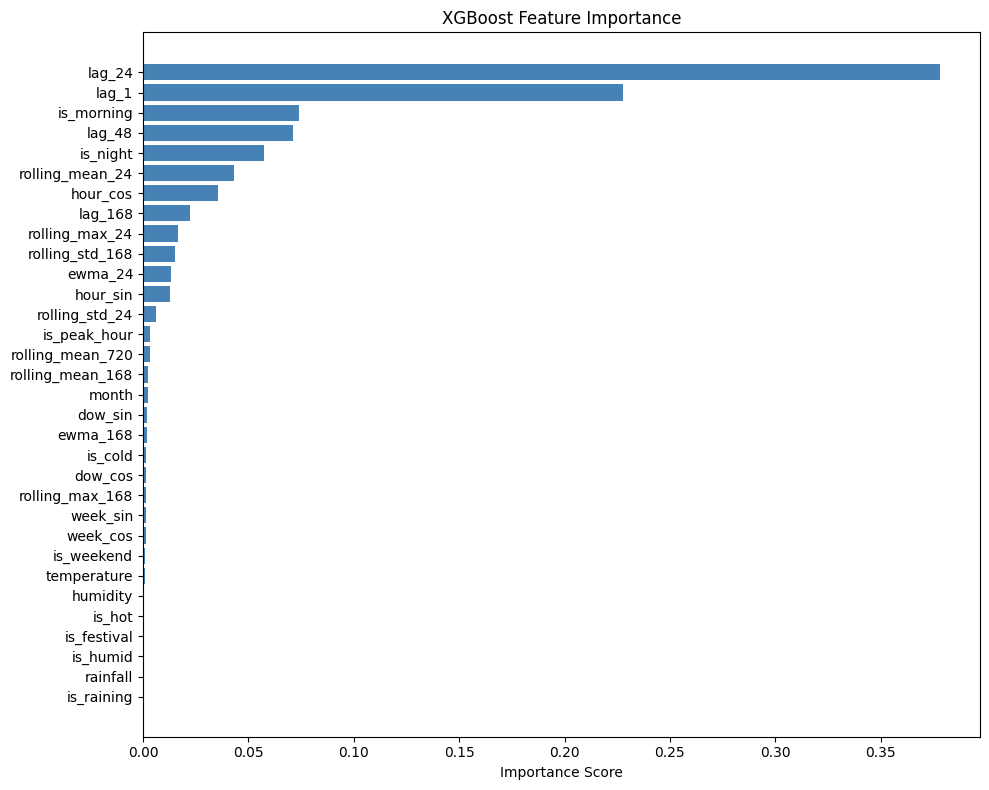

             feature  importance
8             lag_24    0.378213
7              lag_1    0.227872
31        is_morning    0.073850
9             lag_48    0.071401
30          is_night    0.057485
11   rolling_mean_24    0.043288
1           hour_cos    0.035719
10           lag_168    0.022279
16    rolling_max_24    0.016473
15   rolling_std_168    0.015387
18           ewma_24    0.013254
0           hour_sin    0.012865
14    rolling_std_24    0.006235
29      is_peak_hour    0.003288
13  rolling_mean_720    0.003120
12  rolling_mean_168    0.002608
6              month    0.002362
2            dow_sin    0.002140
19          ewma_168    0.001980
25           is_cold    0.001597
3            dow_cos    0.001580
17   rolling_max_168    0.001475
4           week_sin    0.001364
5           week_cos    0.001310
28        is_weekend    0.000880
20       temperature    0.000760
22          humidity    0.000557
24            is_hot    0.000278
27       is_festival    0.000176
26        

In [7]:
# ── Cell 7 — Feature Importance ──────────────────────────────────────
importance = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'][::-1],
         importance['importance'][::-1],
         color='steelblue')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(r'F:\projectss\personal\blinkit_project\noteboook\graph\feature_importance.png', dpi=150)
print("Graph saved!")
plt.show()
print(importance)

Graph saved!


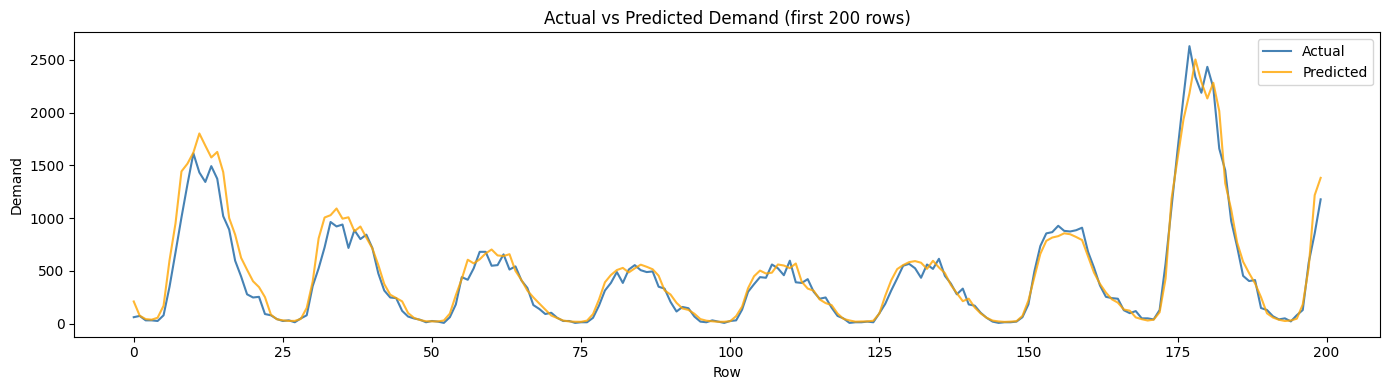

In [8]:
# ── Cell 8 — Actual vs Predicted Plot ────────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(y_real.values[:200],   label='Actual',    color='steelblue')
plt.plot(y_pred_real[:200],     label='Predicted', color='orange', alpha=0.8)
plt.title('Actual vs Predicted Demand (first 200 rows)')
plt.xlabel('Row')
plt.ylabel('Demand')
plt.legend()
plt.tight_layout()
plt.savefig(r'F:\projectss\personal\blinkit_project\noteboook\graph\actual_vs_predicted.png', dpi=150)
print("Graph saved!")
plt.show()

In [9]:
# ── Cell 9 — Save Model ───────────────────────────────────────────────
import os
import pickle

os.makedirs(r'F:\projectss\personal\blinkit_project\models', exist_ok=True)

with open(r'F:\projectss\personal\blinkit_project\models\xgb_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# save feature list too
with open(r'F:\projectss\personal\blinkit_project\models\features.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

print("✅ Model saved!")
print("✅ Features saved!")

✅ Model saved!
✅ Features saved!


In [11]:
# ── Cell 10 — Save Predictions ────────────────────────────────────────
results = test.copy()
results['predicted_demand'] = y_pred_real
results['actual_demand']    = y_real.values
results['error']            = abs(results['actual_demand'] - results['predicted_demand'])

results[[
    'datetime', 'product_id', 'product_name',
    'pincode',  'area_name',
    'actual_demand', 'predicted_demand', 'error'
]].to_csv(
    r'F:\projectss\personal\blinkit_project\data\processed\predictions.csv',
    index=False
)

print(f"✅ Predictions saved!")
print(f"Total predictions : {len(results):,}")
print(f"Avg error         : {results['error'].mean():.2f} units")
print(results[['product_name','area_name','actual_demand','predicted_demand','error']].head(10))

✅ Predictions saved!
Total predictions : 158,426
Avg error         : 66.24 units
       product_name area_name  actual_demand  predicted_demand       error
3840  Yellow Onions     Paldi      60.001594        209.118774  149.117180
3841  Yellow Onions     Paldi      72.002961         74.098129    2.095168
3842  Yellow Onions     Paldi      30.000397         42.043926   12.043530
3843  Yellow Onions     Paldi      30.000397         36.509071    6.508675
3844  Yellow Onions     Paldi      24.000604         54.789036   30.788431
3845  Yellow Onions     Paldi      77.996220        168.474396   90.478176
3846  Yellow Onions     Paldi     348.988396        600.357117  251.368721
3847  Yellow Onions     Paldi     673.991434        949.428223  275.436789
3848  Yellow Onions     Paldi    1005.968892       1442.939331  436.970440
3849  Yellow Onions     Paldi    1319.017140       1515.916992  196.899853


In [12]:
# ── Cell 11 — Inventory Prediction ───────────────────────────────────
# safety stock = extra buffer to avoid stockouts
# reorder point = when to reorder

results['safety_stock']  = (results['predicted_demand'] * 0.20).round(0)
results['reorder_point'] = (results['predicted_demand'] * 1.20).round(0)
results['max_stock']     = (results['predicted_demand'] * 1.50).round(0)

print("=== INVENTORY RECOMMENDATIONS ===")
print(results[[
    'product_name', 'area_name',
    'predicted_demand',
    'safety_stock',
    'reorder_point',
    'max_stock'
]].head(10))

=== INVENTORY RECOMMENDATIONS ===
       product_name area_name  predicted_demand  safety_stock  reorder_point  \
3840  Yellow Onions     Paldi        209.118774          42.0          251.0   
3841  Yellow Onions     Paldi         74.098129          15.0           89.0   
3842  Yellow Onions     Paldi         42.043926           8.0           50.0   
3843  Yellow Onions     Paldi         36.509071           7.0           44.0   
3844  Yellow Onions     Paldi         54.789036          11.0           66.0   
3845  Yellow Onions     Paldi        168.474396          34.0          202.0   
3846  Yellow Onions     Paldi        600.357117         120.0          720.0   
3847  Yellow Onions     Paldi        949.428223         190.0         1139.0   
3848  Yellow Onions     Paldi       1442.939331         289.0         1732.0   
3849  Yellow Onions     Paldi       1515.916992         303.0         1819.0   

      max_stock  
3840      314.0  
3841      111.0  
3842       63.0  
3843       55

In [13]:
# ── Cell 12 — Inventory Summary by Product ───────────────────────────
inventory_summary = results.groupby(['product_name','area_name']).agg(
    avg_predicted_demand = ('predicted_demand', 'mean'),
    avg_safety_stock     = ('safety_stock',     'mean'),
    avg_reorder_point    = ('reorder_point',    'mean'),
    avg_max_stock        = ('max_stock',        'mean'),
    avg_error            = ('error',            'mean'),
).round(0).reset_index()

inventory_summary.to_csv(
    r'F:\projectss\personal\blinkit_project\data\processed\inventory_summary.csv',
    index=False
)

print(f"✅ Inventory summary saved!")
print(f"Total product-area combinations : {len(inventory_summary):,}")
print(inventory_summary.head(10))

✅ Inventory summary saved!
Total product-area combinations : 500
             product_name    area_name  avg_predicted_demand  \
0  100% Whole Wheat Bread       Bakrol                 110.0   
1  100% Whole Wheat Bread       Bareja                  42.0   
2  100% Whole Wheat Bread     Bodakdev                 469.0   
3  100% Whole Wheat Bread         Gota                 372.0   
4  100% Whole Wheat Bread    Maninagar                 250.0   
5  100% Whole Wheat Bread       Naroda                  79.0   
6  100% Whole Wheat Bread  Navrangpura                 537.0   
7  100% Whole Wheat Bread        Paldi                 439.0   
8  100% Whole Wheat Bread    Satellite                 509.0   
9  100% Whole Wheat Bread    Vastrapur                 310.0   

   avg_safety_stock  avg_reorder_point  avg_max_stock  avg_error  
0              22.0              132.0          165.0       23.0  
1               8.0               50.0           63.0       16.0  
2              94.0          